In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Checkerboard_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding
from torch.utils.data import DataLoader

In [2]:
n_rows = 4
n_points = 10000
batch_size = 32

checkerboard_dataset = Checkerboard_Dataset(n_rows, n_points)


loader = DataLoader(checkerboard_dataset, batch_size=batch_size, shuffle = True)
batch = next(iter(loader))
first_sample = batch[0]
print("sample shape of checkerboard dataset", first_sample.shape)

sample shape of checkerboard dataset torch.Size([10000, 2])


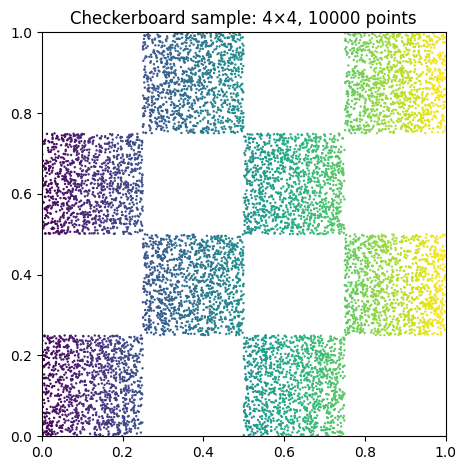

In [3]:
fig,ax = plt.subplots()
ax.scatter(first_sample[:,0],first_sample[:,1],s = 0.5, c= first_sample[:,0], cmap = "viridis")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title(f"Checkerboard sample: {n_rows}×{n_rows}, {n_points} points")
plt.tight_layout()
plt.show()

torch.Size([10000, 2])
torch.Size([10000, 3])


Text(0.5, 0.92, 'Checkerboard on 2d torus')

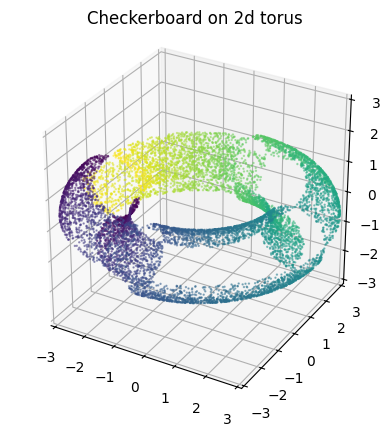

In [4]:
# Lie torus data like checkerboard
Torus_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(Torus_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))
sample = batched_sample[0]
print(sample.shape)
theta1 = sample[:,0]
theta2 = sample[:,1]
# using 3d torus embedding to plot the checkerboard
torusEmbedding = torus_embedding(theta1,theta2)
print(torusEmbedding.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(torusEmbedding[:,0],torusEmbedding[:,1],torusEmbedding[:,2],c=theta1,cmap = "viridis", s = 0.5, alpha = 0.5)
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_zlim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on 2d torus")

Text(0.5, 1.0, 'Checkerboard on -pi, pi coordinate')

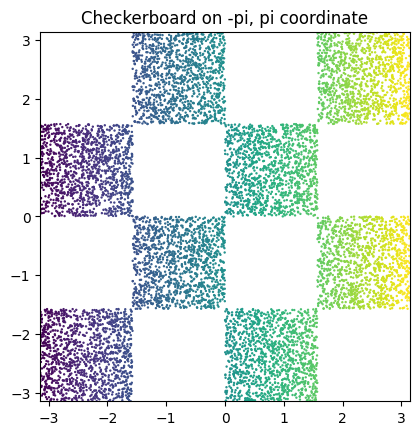

In [5]:
# plot checker board on the -pi, pi coordinate
fig,ax = plt.subplots()
ax.scatter(theta1,theta2,s = 0.5, c=theta1, cmap = "viridis")
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on -pi, pi coordinate")

## Sample Forward of checkerboard dataset from TDM diffusion model.

In [6]:
import src.diffusion as diffusion
import src.sde as sde

model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler")
n_points = 10000
checkerboard_dataset = Checkerboard_Dataset(n_rows, n_points)
matrix_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(matrix_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))
sample = batched_sample[0]
print(sample.shape)
theta1 = sample[:,0]
theta2 = sample[:,1]
print("shape of each batch",batched_sample.shape)
# Fixed times on the forward process
constant_t_forward = (0.01, 0.4, 0.7, 1.0, 15.0)
unconditional_samples = []
scores = []
# sample the forward process at fixed times
for i in range(len(constant_t_forward)):
    unconditional_sample_i, score_i = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = constant_t_forward[i])
    unconditional_samples.append(unconditional_sample_i)
    scores.append(score_i)
# shape: unconditional_samples: (constant_t_forward, batch_size, n_points, 2)
# shape: scores: (constant_t_forward, batch_size, n_points, 2)

SyntaxError: invalid syntax (diffusion.py, line 248)

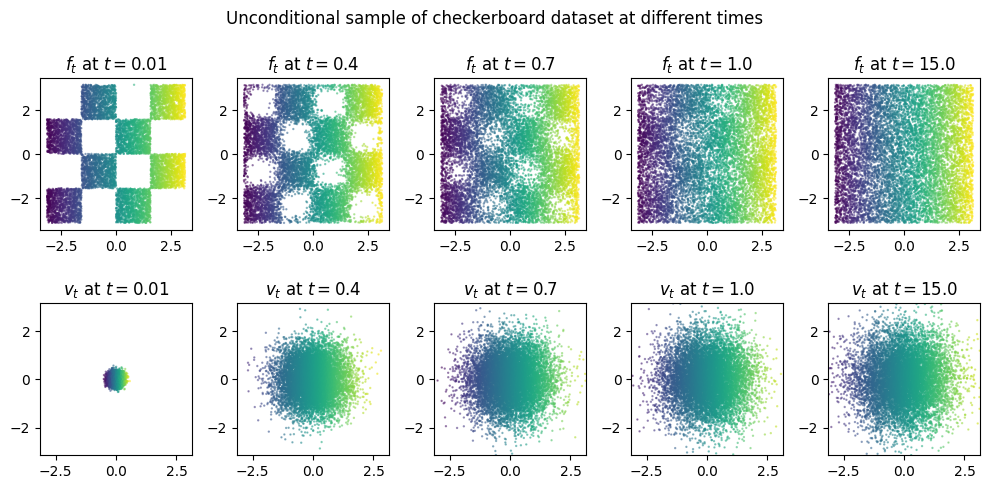

In [ ]:
# extract the first sample of the unconditional samples
# post-process the unconditional samples to get the noised theta1 and theta2
fts_1st_list = []
vts_1st_list = []
theta1_noise_1st_list = []
theta2_noise_1st_list = []
scores_1st_list = []
for ti in range(len(constant_t_forward)):
    vts_ti = unconditional_samples[ti][0]
    fts_ti = unconditional_samples[ti][1]
    fts_1st_ti = fts_ti[0]
    vts_1st_ti = vts_ti[0]
    scores_1st_ti = scores[ti][0]
    theta1_noise_ti = fts_1st_ti[:,0]
    theta2_noise_ti = fts_1st_ti[:,1]
    fts_1st_list.append(fts_1st_ti)
    vts_1st_list.append(vts_1st_ti)
    theta1_noise_1st_list.append(theta1_noise_ti)
    theta2_noise_1st_list.append(theta2_noise_ti)
    scores_1st_list.append(scores_1st_ti)
    if i == 0:
        print("shape of vts",vts_ti.shape)
        print("shape of fts",fts_ti.shape)
        print("shape of score",scores_1st_ti.shape)
        print("shape of fts of the first sample",fts_1st_ti.shape)
        print("shape of vts of the first sample",vts_1st_ti.shape)
        # check the max and min of fts
        print("max of noised theta1 of the first sample",fts_1st_ti[:,0].max())
        print("min of noised theta1 of the first sample",fts_1st_ti[:,0].min())

# plot the unconditional sample for each constant t
fig,ax = plt.subplots(2,len(constant_t_forward),figsize=(10,5))
for i in range(len(constant_t_forward)):
    
    # plot the unconditional sample
    ax[0][i].scatter(theta1_noise_1st_list[i],theta2_noise_1st_list[i],c=theta1_noise_1st_list[i],cmap = "viridis",s = 0.5,alpha = 0.5)
    # ax.set_xlim(-np.pi,np.pi)
    # ax.set_ylim(-np.pi,np.pi)
    ax[0][i].set_aspect("equal")
    ax[0][i].set_title("$f_t$ at $t=" + str(constant_t_forward[i]) + "$")
    ax[1][i].scatter(vts_1st_list[i][:,0],vts_1st_list[i][:,1],c=vts_1st_list[i][:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
    ax[1][i].set_aspect("equal")
    ax[1][i].set_xlim(-np.pi,np.pi)
    ax[1][i].set_ylim(-np.pi,np.pi)
    ax[1][i].set_title("$v_t$ at $t=" + str(constant_t_forward[i]) + "$")
fig.suptitle("Unconditional sample of checkerboard dataset at different times") 
plt.tight_layout()
plt.show()

## Check the score of the forward process at exact time t

torch.Size([1000, 2])
tensor(3.1311)
tensor(-3.1284)


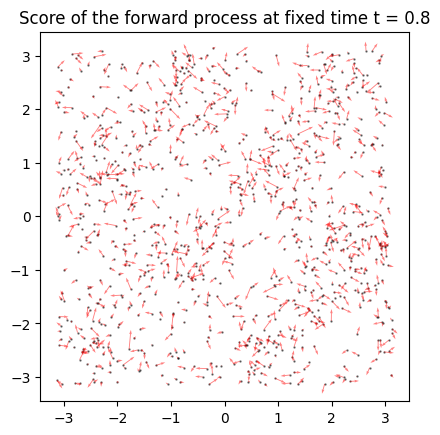

In [ ]:
# Test on the smaller dataset
n_points = 1000
batch_size = 32
checkerboard_dataset = Checkerboard_Dataset(n_rows, n_points)
Lie_dataset = TorusLieWrapper(checkerboard_dataset)
Angle_dataset = AngleTorusWrapper(Lie_dataset)
data_loader_small = DataLoader(Angle_dataset, batch_size=batch_size, shuffle = True)

batched_sample = next(iter(data_loader_small))

fixed_t = 0.8
# sample the forward process at fixed time
model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler")
unconditional_sample, score = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = fixed_t)

vts_batched = unconditional_sample[0]
fts_batched = unconditional_sample[1]
fts_1st = fts_batched[0]
print(fts_1st.shape)
vts_1st = vts_batched[0]
scores_1st = score[0]
theta1_noise_1st = fts_1st[:,0]
theta2_noise_1st = fts_1st[:,1]
print(max(theta1_noise_1st))
print(min(theta1_noise_1st))
# plot the score of the forward process at fixed time

fig,ax = plt.subplots()
ax.scatter(theta1_noise_1st,theta2_noise_1st,c="black",s = 0.5,alpha = 0.5)
ax.quiver(theta1_noise_1st,theta2_noise_1st,scores_1st[:,0],scores_1st[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Score of the forward process at fixed time t = " + str(fixed_t))
plt.show()




/home/jizho/.conda/envs/diffusion-playground-torch/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


torch.Size([1, 10000, 2])
tensor([[[-0.3445, -0.3450],
         [-0.3745, -0.3194],
         [-0.4028, -0.2924],
         ...,
         [ 0.1964, -0.1487],
         [ 0.1271, -0.1635],
         [ 0.0596, -0.1779]]], grad_fn=<ViewBackward0>)
tensor([[0.3672, 0.3594]], grad_fn=<StdBackward0>) tensor([[-0.3445, -0.3450],
        [-0.3745, -0.3194],
        [-0.4028, -0.2924],
        ...,
        [ 0.1964, -0.1487],
        [ 0.1271, -0.1635],
        [ 0.0596, -0.1779]], grad_fn=<MeanBackward1>)
torch.Size([10000, 2])
tensor(-0.9505) tensor(1.0969)
tensor(-0.9460) tensor(0.9467)


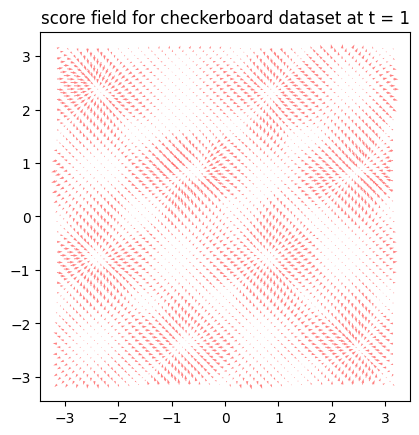

In [7]:
from src.scoreNN import TDM_SimpleScoreMLP
x_lifting_dim = 32
time_embedding_dim = 32  # must be even
hidden_dim = [64, 64]
output_dim = 2
score_nn = TDM_SimpleScoreMLP(
    dim = 2, 
    x_lifting_dim = x_lifting_dim, 
    time_embedding_dim = time_embedding_dim, 
    hidden_dim = hidden_dim, 
    output_dim = output_dim,
    with_sincos_position=True,
    only_sincos_position=False
)
state_dict = torch.load("simple_score_mlp_checkerboard.pt", map_location="cpu")
score_nn.load_state_dict(state_dict)


x_test = torch.linspace(-np.pi, np.pi, 100)
y_test = torch.linspace(-np.pi, np.pi, 100)
x_test, y_test = torch.meshgrid(x_test, y_test)
x_test = x_test.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
x_test = torch.cat([x_test, y_test], dim=-1)

x_test_batched = x_test[None,:,:]
print(x_test_batched.shape)
t_scalar = 1
t_test = torch.full((1, 10000, 1), t_scalar)   # (1, 10000, 1)
v_test = torch.ones_like(x_test_batched) * 0

score = score_nn(x_test_batched, v_test, t_test)
print(score)
print(score.std(dim=1),score.mean(dim=0))
score_test = score.detach().cpu().squeeze(0)
print(score_test.shape)
print(min(score_test[:,0]),max(score_test[:,0]))
print(min(score_test[:,1]),max(score_test[:,1]))

# shows every 3 points
score_test = score_test[::3,:]
x_test = x_test[::3,:]

fig,ax = plt.subplots()
# ax.scatter(x_test[:,0],x_test[:,1],c=x_test[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.quiver(x_test[:,0],x_test[:,1],score_test[:,0],score_test[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"score field for checkerboard dataset at t = {t_scalar}")
plt.show()



